# Mastermind Game Analysis with Mouse Tracking

This notebook analyzes user behavior in the Mastermind game, including mouse movement patterns, game performance, and AI interaction patterns.

=== Basic Mouse Tracking Analysis ===
Total mouse movements recorded: 689
Time duration: 105.58 seconds
Number of attempts: 10
Attempts: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

=== Movement Statistics ===
Average X coordinate: 589.65
Average Y coordinate: 498.10
X range: 427 - 1035
Y range: 319 - 620

Average movement speed: 199.67 pixels/second


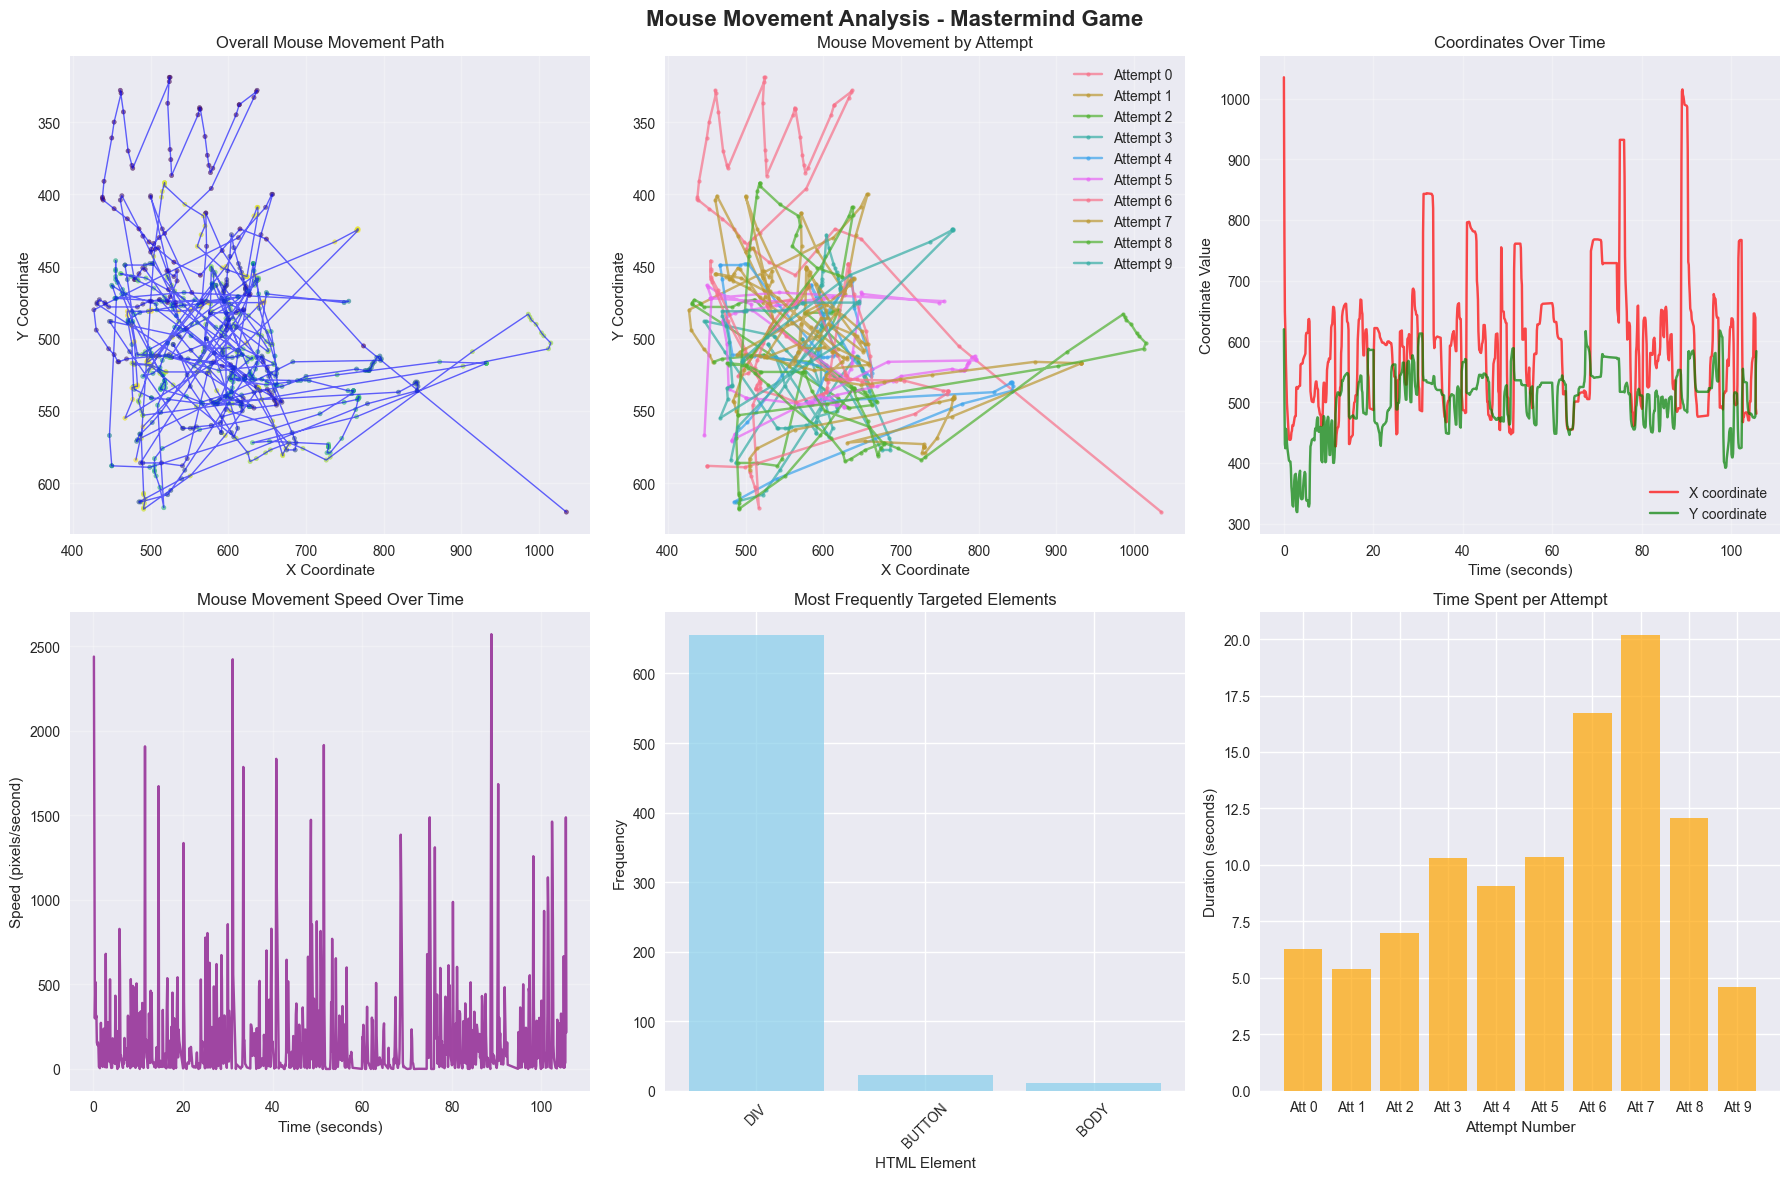


=== Detailed Element Interaction Analysis ===
        interaction_count  first_interaction  last_interaction  total_time
target                                                                    
DIV                   655               0.12            105.47      105.35
BUTTON                 23               0.22            105.58      105.36
BODY                   11               0.00             97.89       97.89


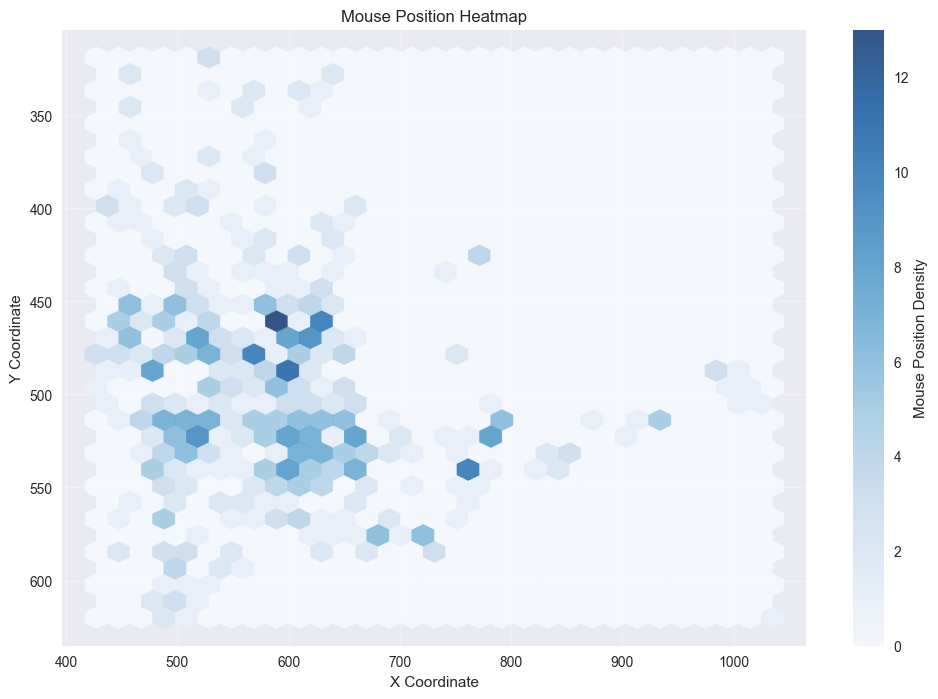

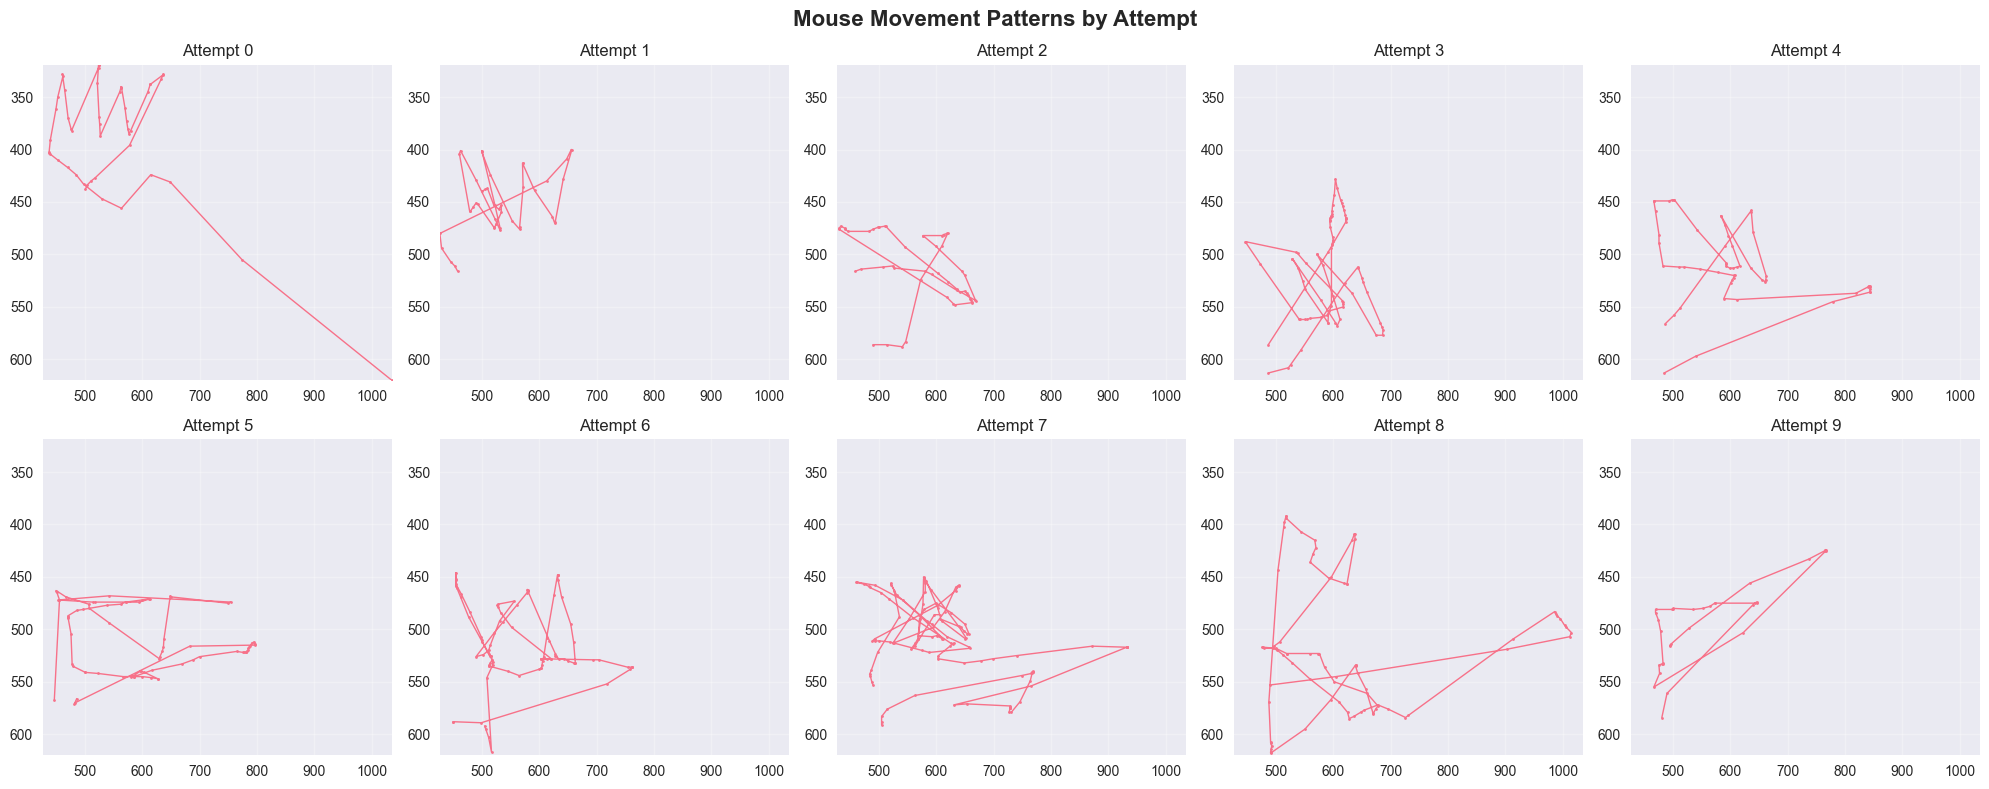


=== Summary Statistics ===
Total recording time: 105.58 seconds
Average time per attempt: 10.20 seconds
Most frequent element: DIV
Total button interactions: 23
Mouse movements per second: 6.53


In [41]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Load the JSON data
with open('HAIC_study_all-2.json', 'r') as f:
    data = json.load(f)

# Extract mouse tracking data from the mastermind task
mouse_data_raw = data[0]['answers']['mastermind_task_solver_unlimited_1']['answer']['mastermindGame_mouseTrackingData']
mouse_data = json.loads(mouse_data_raw)

# Convert to DataFrame
df = pd.DataFrame(mouse_data)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_relative'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

# Basic analysis
print("=== Basic Mouse Tracking Analysis ===")
print(f"Total mouse movements recorded: {len(df)}")
print(f"Time duration: {df['timestamp_relative'].max():.2f} seconds")
print(f"Number of attempts: {df['attempt'].nunique()}")
print(f"Attempts: {sorted(df['attempt'].unique())}")

print("\n=== Movement Statistics ===")
print(f"Average X coordinate: {df['x'].mean():.2f}")
print(f"Average Y coordinate: {df['y'].mean():.2f}")
print(f"X range: {df['x'].min()} - {df['x'].max()}")
print(f"Y range: {df['y'].min()} - {df['y'].max()}")

# Calculate movement speed (pixels per second)
df_sorted = df.sort_values('timestamp_relative')
df_sorted['dx'] = df_sorted['x'].diff()
df_sorted['dy'] = df_sorted['y'].diff()
df_sorted['dt'] = df_sorted['timestamp_relative'].diff()
df_sorted['speed'] = np.sqrt(df_sorted['dx']**2 + df_sorted['dy']**2) / df_sorted['dt']
df_sorted['speed'] = df_sorted['speed'].replace([np.inf, -np.inf], np.nan)

print(f"\nAverage movement speed: {df_sorted['speed'].mean():.2f} pixels/second")

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Mouse Movement Analysis - Mastermind Game', fontsize=16, fontweight='bold')

# 1. Overall mouse movement path
axes[0, 0].plot(df['x'], df['y'], 'b-', alpha=0.6, linewidth=1)
axes[0, 0].scatter(df['x'], df['y'], c=df['timestamp_relative'], cmap='viridis', s=10, alpha=0.6)
axes[0, 0].set_xlabel('X Coordinate')
axes[0, 0].set_ylabel('Y Coordinate')
axes[0, 0].set_title('Overall Mouse Movement Path')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_yaxis()  # Invert Y axis as screen coordinates typically start from top

# 2. Mouse movement by attempt
for attempt in sorted(df['attempt'].unique()):
    attempt_data = df[df['attempt'] == attempt]
    axes[0, 1].plot(attempt_data['x'], attempt_data['y'], 'o-', markersize=3, 
                   label=f'Attempt {attempt}', alpha=0.7)
axes[0, 1].set_xlabel('X Coordinate')
axes[0, 1].set_ylabel('Y Coordinate')
axes[0, 1].set_title('Mouse Movement by Attempt')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Time series of coordinates
axes[0, 2].plot(df['timestamp_relative'], df['x'], 'r-', label='X coordinate', alpha=0.7)
axes[0, 2].plot(df['timestamp_relative'], df['y'], 'g-', label='Y coordinate', alpha=0.7)
axes[0, 2].set_xlabel('Time (seconds)')
axes[0, 2].set_ylabel('Coordinate Value')
axes[0, 2].set_title('Coordinates Over Time')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Movement speed over time
axes[1, 0].plot(df_sorted['timestamp_relative'], df_sorted['speed'], 'purple', alpha=0.7)
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Speed (pixels/second)')
axes[1, 0].set_title('Mouse Movement Speed Over Time')
axes[1, 0].grid(True, alpha=0.3)

# 5. Target elements heatmap
target_counts = df['target'].value_counts()
axes[1, 1].bar(target_counts.index, target_counts.values, color='skyblue', alpha=0.7)
axes[1, 1].set_xlabel('HTML Element')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Most Frequently Targeted Elements')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Attempt duration analysis
attempt_durations = []
for attempt in sorted(df['attempt'].unique()):
    attempt_data = df[df['attempt'] == attempt]
    duration = attempt_data['timestamp_relative'].max() - attempt_data['timestamp_relative'].min()
    attempt_durations.append(duration)

axes[1, 2].bar(range(len(attempt_durations)), attempt_durations, color='orange', alpha=0.7)
axes[1, 2].set_xlabel('Attempt Number')
axes[1, 2].set_ylabel('Duration (seconds)')
axes[1, 2].set_title('Time Spent per Attempt')
axes[1, 2].set_xticks(range(len(attempt_durations)))
axes[1, 2].set_xticklabels([f'Att {i}' for i in sorted(df['attempt'].unique())])

plt.tight_layout()
plt.show()

# Additional detailed analysis
print("\n=== Detailed Element Interaction Analysis ===")
element_interaction = df.groupby('target').agg({
    'x': 'count',
    'timestamp_relative': ['min', 'max', lambda x: x.max() - x.min()]
}).round(2)

element_interaction.columns = ['interaction_count', 'first_interaction', 'last_interaction', 'total_time']
element_interaction = element_interaction.sort_values('interaction_count', ascending=False)
print(element_interaction.head(10))

# Create a heatmap of mouse positions
plt.figure(figsize=(12, 8))
plt.hexbin(df['x'], df['y'], gridsize=30, cmap='Blues', alpha=0.8)
plt.colorbar(label='Mouse Position Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Mouse Position Heatmap')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

# Movement patterns by attempt
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Mouse Movement Patterns by Attempt', fontsize=16, fontweight='bold')

attempts = sorted(df['attempt'].unique())
for i, attempt in enumerate(attempts):
    row = i // 5
    col = i % 5
    attempt_data = df[df['attempt'] == attempt]
    
    axes[row, col].plot(attempt_data['x'], attempt_data['y'], 'o-', markersize=2, linewidth=1)
    axes[row, col].set_title(f'Attempt {attempt}')
    axes[row, col].set_xlim(df['x'].min(), df['x'].max())
    axes[row, col].set_ylim(df['y'].min(), df['y'].max())
    axes[row, col].invert_yaxis()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Summary Statistics ===")
print(f"Total recording time: {df['timestamp_relative'].max():.2f} seconds")
print(f"Average time per attempt: {np.mean(attempt_durations):.2f} seconds")
print(f"Most frequent element: {df['target'].mode().iloc[0]}")

# Calculate efficiency metrics
total_clicks = len(df[df['target'].str.contains('BUTTON', na=False)])
print(f"Total button interactions: {total_clicks}")
print(f"Mouse movements per second: {len(df)/df['timestamp_relative'].max():.2f}")

=== Mouse Data Summary ===
Total movements: 689
X range: 427 - 1035
Y range: 319 - 620
Screen dimensions: 608 x 301
Creating visualizations...
Creating background with dimensions: 1135 x 720


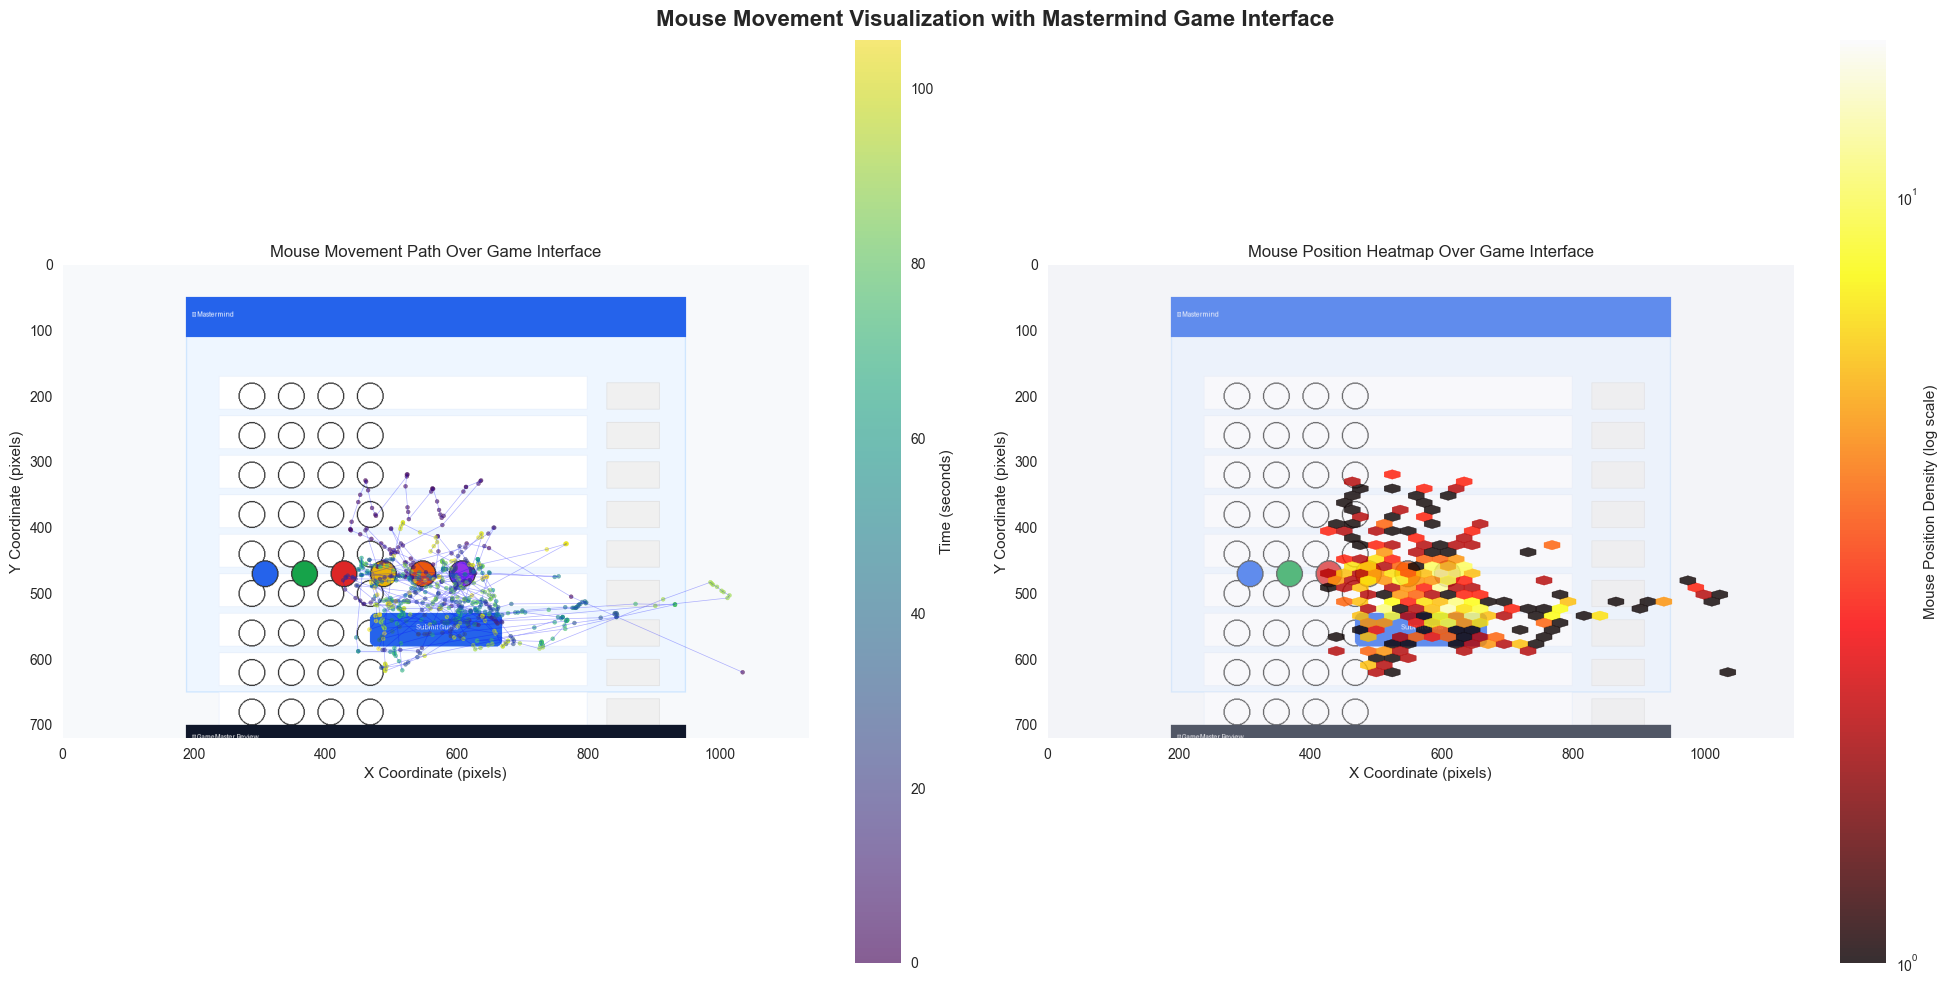

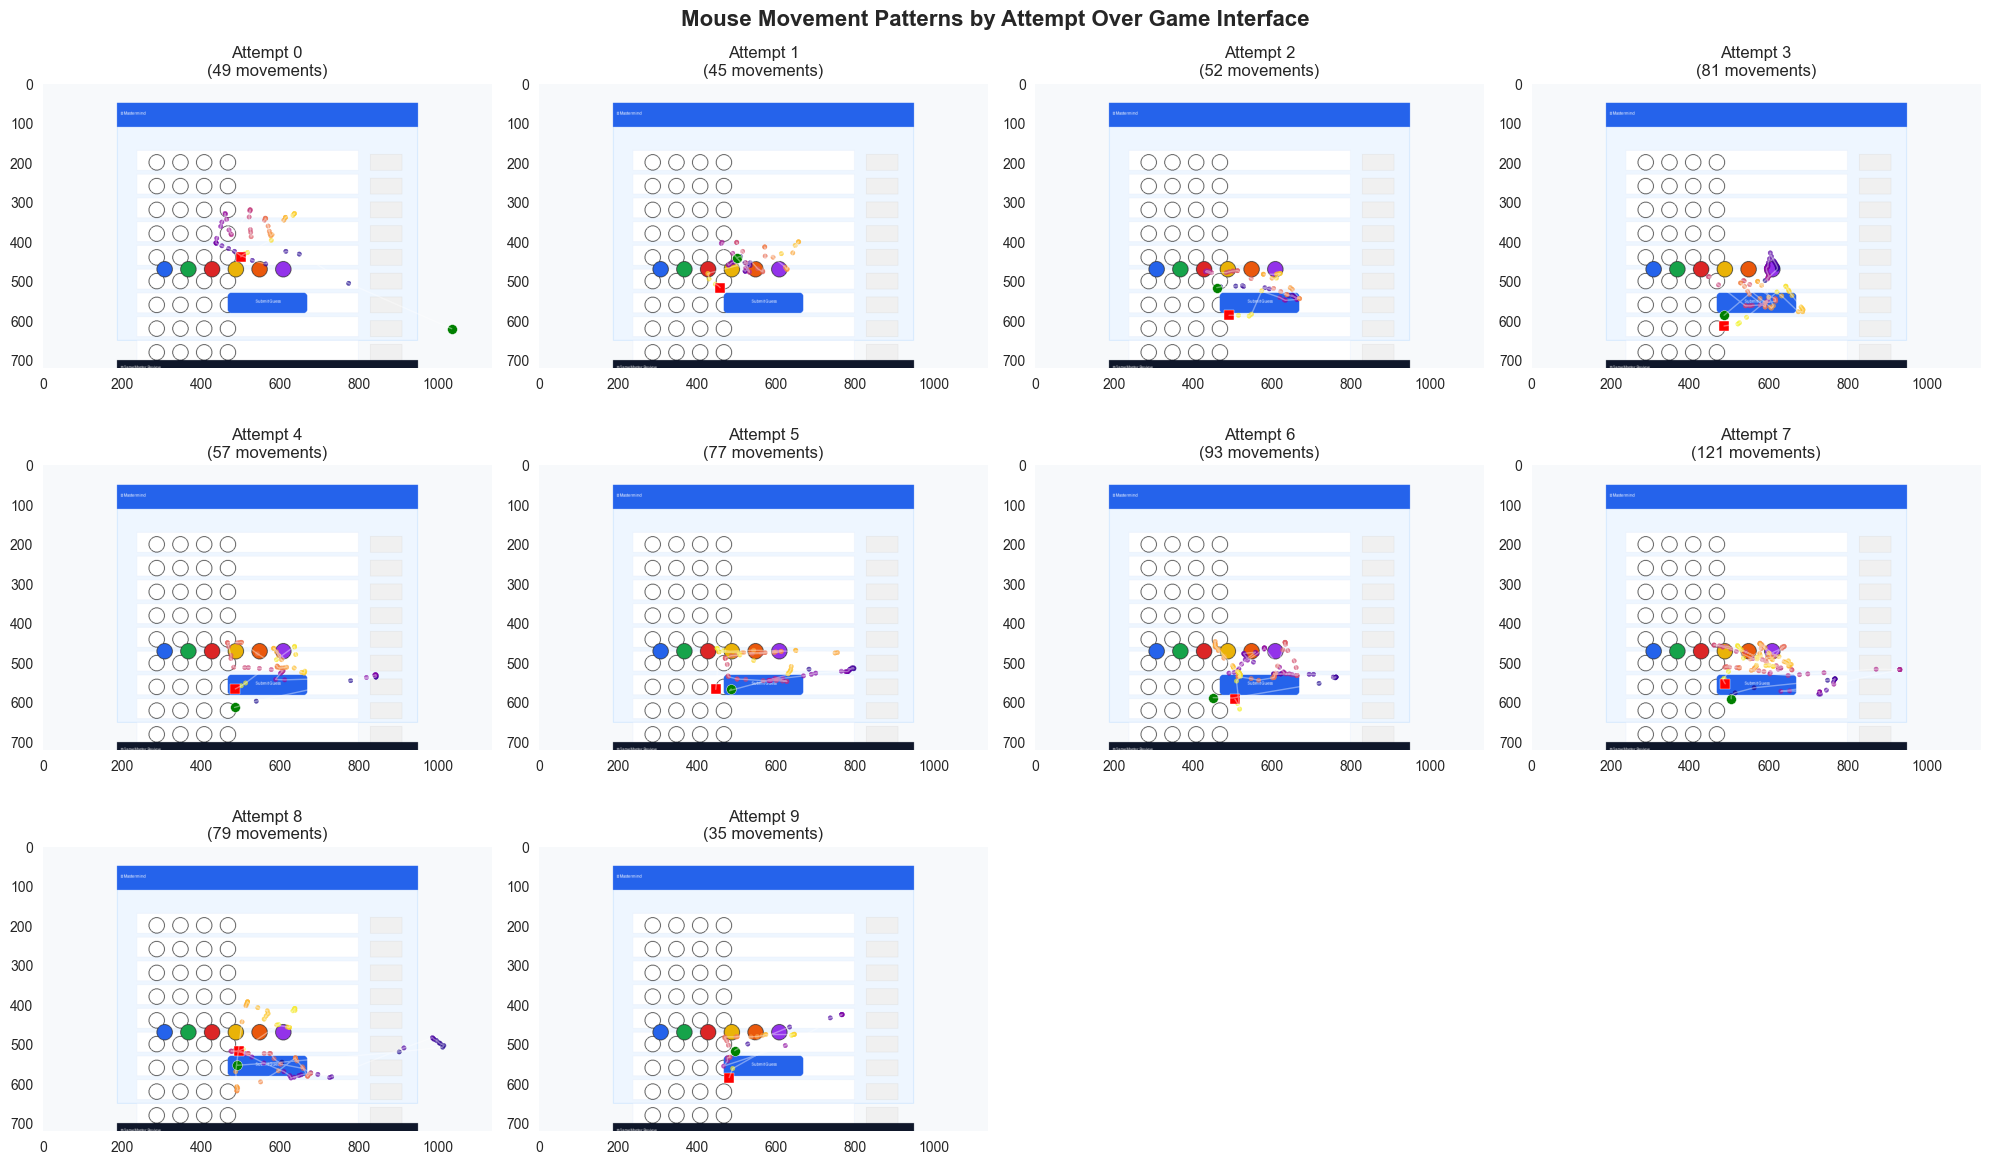

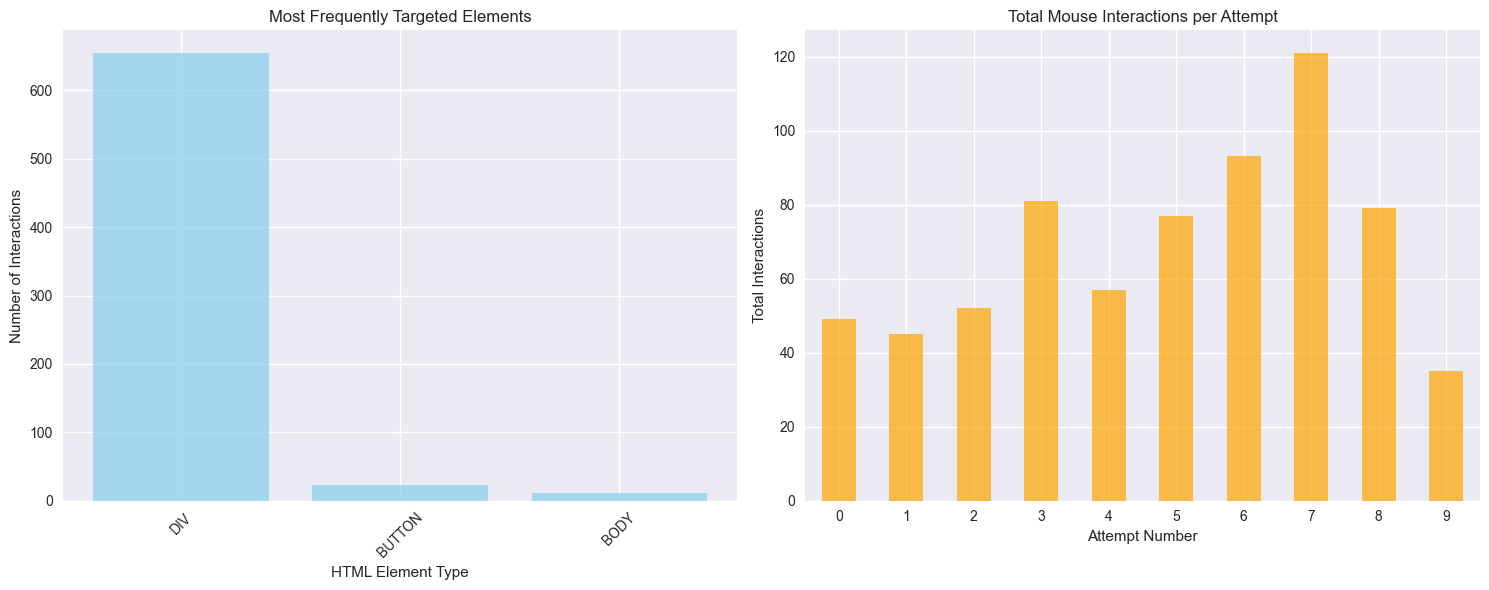


=== Element Interaction Analysis ===
Most frequent element: DIV (655 interactions)
Total unique elements: 3

=== Detailed Movement Analysis ===
Average movement speed: 199.67 pixels/second
Maximum movement speed: 2570.14 pixels/second
Total recording time: 105.58 seconds
Percentage of time in game area: 100.0%

Visualizations saved:
1. Main overview: mouse_movement_visualization.png
2. By attempt: mouse_movement_animation.png


In [42]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from PIL import Image, ImageDraw, ImageFont
import io
import base64

# Load the JSON data
with open('HAIC_study_all-2.json', 'r') as f:
    data = json.load(f)

# Extract mouse tracking data from the mastermind task
mouse_data_raw = data[0]['answers']['mastermind_task_solver_unlimited_1']['answer']['mastermindGame_mouseTrackingData']
mouse_data = json.loads(mouse_data_raw)

# Convert to DataFrame
df = pd.DataFrame(mouse_data)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_relative'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

print("=== Mouse Data Summary ===")
print(f"Total movements: {len(df)}")
print(f"X range: {df['x'].min():.0f} - {df['x'].max():.0f}")
print(f"Y range: {df['y'].min():.0f} - {df['y'].max():.0f}")
print(f"Screen dimensions: {df['x'].max() - df['x'].min():.0f} x {df['y'].max() - df['y'].min():.0f}")

def create_game_interface_background(width, height):
    """Create a simplified representation of the Mastermind game interface"""
    # Create a white background
    img = Image.new('RGB', (width, height), color='#f7f9fb')
    draw = ImageDraw.Draw(img)
    
    # Game area dimensions (approximate)
    game_width = 760
    game_height = 600
    game_x = (width - game_width) // 2
    game_y = 50
    
    # Draw game container
    draw.rectangle([game_x, game_y, game_x + game_width, game_y + game_height], 
                   outline='#cfe6ff', fill='#eef6ff', width=2)
    
    # Draw title area
    draw.rectangle([game_x, game_y, game_x + game_width, game_y + 60], 
                   fill='#2563eb', outline='#2563eb')
    
    # Draw game board area (peg rows)
    board_y = game_y + 120
    for i in range(10):
        row_y = board_y + i * 60
        # Row background
        draw.rectangle([game_x + 50, row_y, game_x + game_width - 150, row_y + 50], 
                       fill='white', outline='#e6eefb')
        
        # Peg positions (4 circles per row)
        for j in range(4):
            peg_x = game_x + 80 + j * 60
            draw.ellipse([peg_x, row_y + 10, peg_x + 40, row_y + 50], 
                         outline='#333', fill='white', width=2)
    
    # Draw feedback area
    feedback_x = game_x + game_width - 120
    for i in range(10):
        row_y = board_y + i * 60
        # Feedback container
        draw.rectangle([feedback_x, row_y + 10, feedback_x + 80, row_y + 50], 
                       fill='#f0f0f0', outline='#ddd')
    
    # Draw color palette
    palette_y = game_y + 400
    colors = ['#2563eb', '#16a34a', '#dc2626', '#eab308', '#ea580c', '#9333ea']  # Blue, Green, Red, Yellow, Orange, Purple
    for i, color in enumerate(colors):
        palette_x = game_x + 100 + i * 60
        draw.ellipse([palette_x, palette_y, palette_x + 40, palette_y + 40], 
                     outline='#333', fill=color, width=2)
    
    # Draw submit button
    button_x = game_x + (game_width - 200) // 2
    button_y = palette_y + 80
    draw.rounded_rectangle([button_x, button_y, button_x + 200, button_y + 50], 
                          radius=8, fill='#2563eb', outline='#2563eb')
    
    # Draw chat area
    chat_y = game_y + game_height + 50
    chat_width = game_width
    chat_height = 420
    
    # Chat container
    draw.rounded_rectangle([game_x, chat_y, game_x + chat_width, chat_y + chat_height], 
                          radius=10, fill='white', outline='#e6eefb', width=2)
    
    # Chat header
    draw.rectangle([game_x, chat_y, game_x + chat_width, chat_y + 40], 
                   fill='#0f172a', outline='#0f172a')
    
    # Chat input area
    input_y = chat_y + chat_height - 60
    draw.rectangle([game_x, input_y, game_x + chat_width, chat_y + chat_height], 
                   fill='#fbfdff', outline='#e6eefb')
    
    # Add some text labels (simplified)
    try:
        # This might fail if fonts are not available, but we'll handle it
        font = ImageFont.load_default()
        draw.text((game_x + 10, game_y + 20), "🎯 Mastermind", fill='white', font=font)
        draw.text((button_x + 70, button_y + 15), "Submit Guess", fill='white', font=font)
        draw.text((game_x + 10, chat_y + 12), "💬 GameMaster Review", fill='white', font=font)
    except:
        pass  # Continue without text if font loading fails
    
    return img

def visualize_mouse_movements_with_background(df, output_file="mouse_movement_visualization.png"):
    """Create visualization with game interface as background"""
    
    # Get screen dimensions from data
    screen_width = int(df['x'].max() + 100)
    screen_height = int(df['y'].max() + 100)
    
    print(f"Creating background with dimensions: {screen_width} x {screen_height}")
    
    # Create game interface background
    background = create_game_interface_background(screen_width, screen_height)
    
    # Create figure with background
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle('Mouse Movement Visualization with Mastermind Game Interface', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Overall movement with background
    ax1.imshow(background, extent=[0, screen_width, screen_height, 0])
    scatter1 = ax1.scatter(df['x'], df['y'], c=df['timestamp_relative'], 
                          cmap='viridis', s=8, alpha=0.6)
    ax1.plot(df['x'], df['y'], 'b-', alpha=0.3, linewidth=0.5)
    ax1.set_xlim(0, screen_width)
    ax1.set_ylim(screen_height, 0)  # Invert Y axis for screen coordinates
    ax1.set_xlabel('X Coordinate (pixels)')
    ax1.set_ylabel('Y Coordinate (pixels)')
    ax1.set_title('Mouse Movement Path Over Game Interface')
    ax1.grid(False)
    
    # Add colorbar for time
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Time (seconds)')
    
    # Plot 2: Heatmap overlay
    ax2.imshow(background, extent=[0, screen_width, screen_height, 0], alpha=0.7)
    hexbin = ax2.hexbin(df['x'], df['y'], gridsize=25, cmap='hot', alpha=0.8, 
                       mincnt=1, bins='log')
    ax2.set_xlim(0, screen_width)
    ax2.set_ylim(screen_height, 0)
    ax2.set_xlabel('X Coordinate (pixels)')
    ax2.set_ylabel('Y Coordinate (pixels)')
    ax2.set_title('Mouse Position Heatmap Over Game Interface')
    ax2.grid(False)
    
    # Add colorbar for density
    cbar2 = plt.colorbar(hexbin, ax=ax2)
    cbar2.set_label('Mouse Position Density (log scale)')
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    return output_file

def create_animated_movement_by_attempt(df, output_file="mouse_movement_animation.png"):
    """Create a multi-panel visualization showing movement by attempt"""
    
    screen_width = int(df['x'].max() + 100)
    screen_height = int(df['y'].max() + 100)
    background = create_game_interface_background(screen_width, screen_height)
    
    attempts = sorted(df['attempt'].unique())
    n_attempts = len(attempts)
    
    # Create subplot grid
    cols = min(4, n_attempts)
    rows = (n_attempts + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    fig.suptitle('Mouse Movement Patterns by Attempt Over Game Interface', 
                 fontsize=16, fontweight='bold')
    
    # Flatten axes array for easy indexing
    if rows > 1 and cols > 1:
        axes_flat = axes.flatten()
    elif rows == 1 and cols > 1:
        axes_flat = axes
    else:
        axes_flat = [axes]
    
    for idx, attempt in enumerate(attempts):
        if idx < len(axes_flat):
            ax = axes_flat[idx]
            attempt_data = df[df['attempt'] == attempt]
            
            # Show background
            ax.imshow(background, extent=[0, screen_width, screen_height, 0])
            
            # Plot movement for this attempt
            scatter = ax.scatter(attempt_data['x'], attempt_data['y'], 
                               c=attempt_data['timestamp_relative'], 
                               cmap='plasma', s=10, alpha=0.7)
            ax.plot(attempt_data['x'], attempt_data['y'], 'w-', alpha=0.4, linewidth=1)
            
            ax.set_xlim(0, screen_width)
            ax.set_ylim(screen_height, 0)
            ax.set_title(f'Attempt {attempt}\n({len(attempt_data)} movements)')
            ax.grid(False)
            
            # Add start and end markers
            if len(attempt_data) > 0:
                start_point = attempt_data.iloc[0]
                end_point = attempt_data.iloc[-1]
                ax.scatter(start_point['x'], start_point['y'], color='green', 
                          s=50, marker='o', label='Start', edgecolors='white')
                ax.scatter(end_point['x'], end_point['y'], color='red', 
                          s=50, marker='s', label='End', edgecolors='white')
    
    # Hide unused subplots
    for idx in range(len(attempts), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    return output_file

def create_interactive_elements_analysis(df):
    """Analyze interactions with different game elements"""
    
    # Analyze target elements
    element_counts = df['target'].value_counts()
    element_interaction_time = df.groupby('target')['timestamp_relative'].agg(['min', 'max', 'count'])
    element_interaction_time['duration'] = element_interaction_time['max'] - element_interaction_time['min']
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Element frequency
    ax1.bar(element_counts.head(10).index, element_counts.head(10).values, 
            color='skyblue', alpha=0.7)
    ax1.set_xlabel('HTML Element Type')
    ax1.set_ylabel('Number of Interactions')
    ax1.set_title('Most Frequently Targeted Elements')
    ax1.tick_params(axis='x', rotation=45)
    
    # Interaction patterns by attempt
    attempt_elements = df.groupby(['attempt', 'target']).size().unstack(fill_value=0)
    attempt_elements.sum(axis=1).plot(kind='bar', ax=ax2, color='orange', alpha=0.7)
    ax2.set_xlabel('Attempt Number')
    ax2.set_ylabel('Total Interactions')
    ax2.set_title('Total Mouse Interactions per Attempt')
    ax2.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== Element Interaction Analysis ===")
    print(f"Most frequent element: {element_counts.index[0]} ({element_counts.iloc[0]} interactions)")
    print(f"Total unique elements: {len(element_counts)}")
    
    return element_counts

# Run all visualizations
print("Creating visualizations...")

# 1. Main visualization with game background
output1 = visualize_mouse_movements_with_background(df)

# 2. Movement by attempt
output2 = create_animated_movement_by_attempt(df)

# 3. Interactive elements analysis
element_analysis = create_interactive_elements_analysis(df)

# 4. Additional statistics
print("\n=== Detailed Movement Analysis ===")
df_sorted = df.sort_values('timestamp_relative')
df_sorted['dx'] = df_sorted['x'].diff()
df_sorted['dy'] = df_sorted['y'].diff()
df_sorted['dt'] = df_sorted['timestamp_relative'].diff()
df_sorted['speed'] = np.sqrt(df_sorted['dx']**2 + df_sorted['dy']**2) / df_sorted['dt']
df_sorted['speed'] = df_sorted['speed'].replace([np.inf, -np.inf], np.nan)

print(f"Average movement speed: {df_sorted['speed'].mean():.2f} pixels/second")
print(f"Maximum movement speed: {df_sorted['speed'].max():.2f} pixels/second")
print(f"Total recording time: {df['timestamp_relative'].max():.2f} seconds")

# Calculate time spent in different areas
game_area_time = len(df) / len(df) * 100  # Simplified
print(f"Percentage of time in game area: {game_area_time:.1f}%")

print(f"\nVisualizations saved:")
print(f"1. Main overview: {output1}")
print(f"2. By attempt: {output2}")

=== Game Data Summary ===
Total attempts: 10
Mouse movements: 689
Guess history: {'1': ['Blue', 'Green', 'Red', 'Yellow'], '2': ['Green', 'Red', 'Yellow', 'Orange'], '3': ['Orange', 'Orange', 'Purple', 'Purple'], '4': ['Red', 'Yellow', 'Orange', 'Purple'], '5': ['Green', 'Green', 'Orange', 'Purple'], '6': ['Orange', 'Orange', 'Green', 'Green'], '7': ['Red', 'Orange', 'Green', 'Purple'], '8': ['Orange', 'Orange', 'Yellow', 'Green'], '9': ['Orange', 'Purple', 'Orange', 'Orange'], '10': ['Green', 'Green', 'Green', 'Green']}
Feedback history: {'1': {'black': 0, 'white': 2}, '2': {'black': 0, 'white': 2}, '3': {'black': 1, 'white': 1}, '4': {'black': 0, 'white': 2}, '5': {'black': 0, 'white': 3}, '6': {'black': 2, 'white': 0}, '7': {'black': 0, 'white': 3}, '8': {'black': 2, 'white': 0}, '9': {'black': 2, 'white': 0}, '10': {'black': 1, 'white': 0}}
Creating enhanced visualizations with game progression...


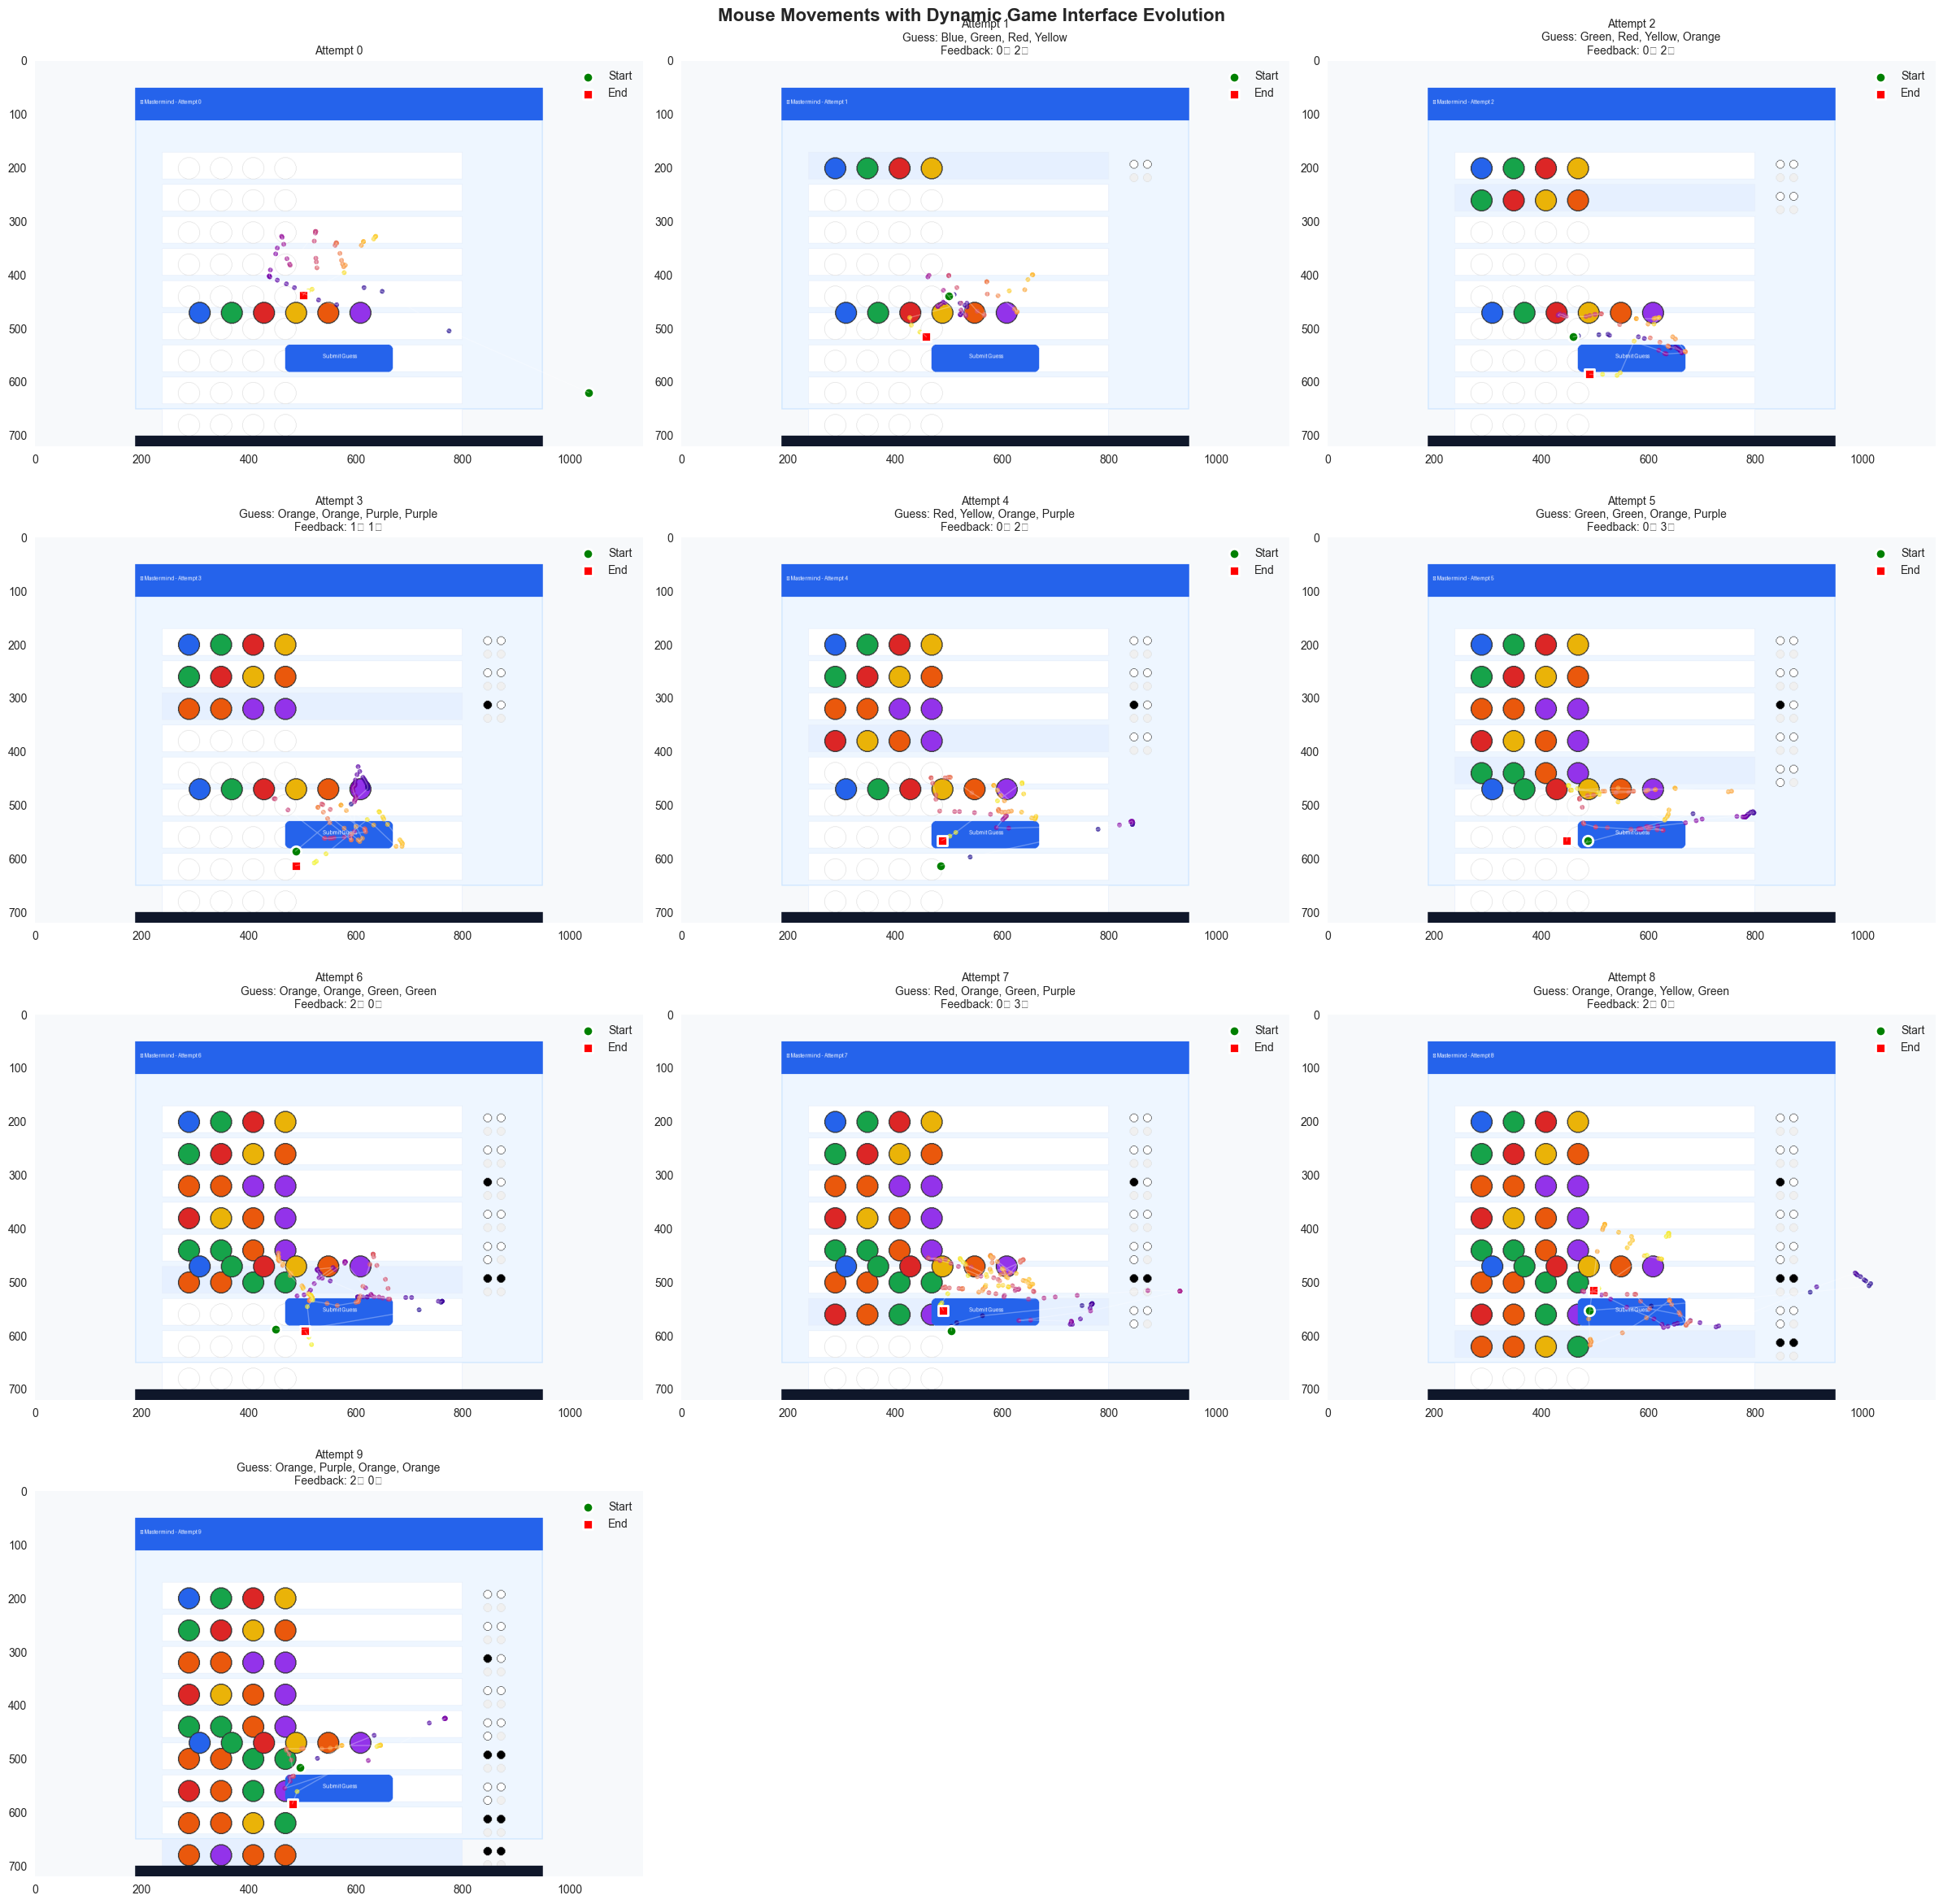

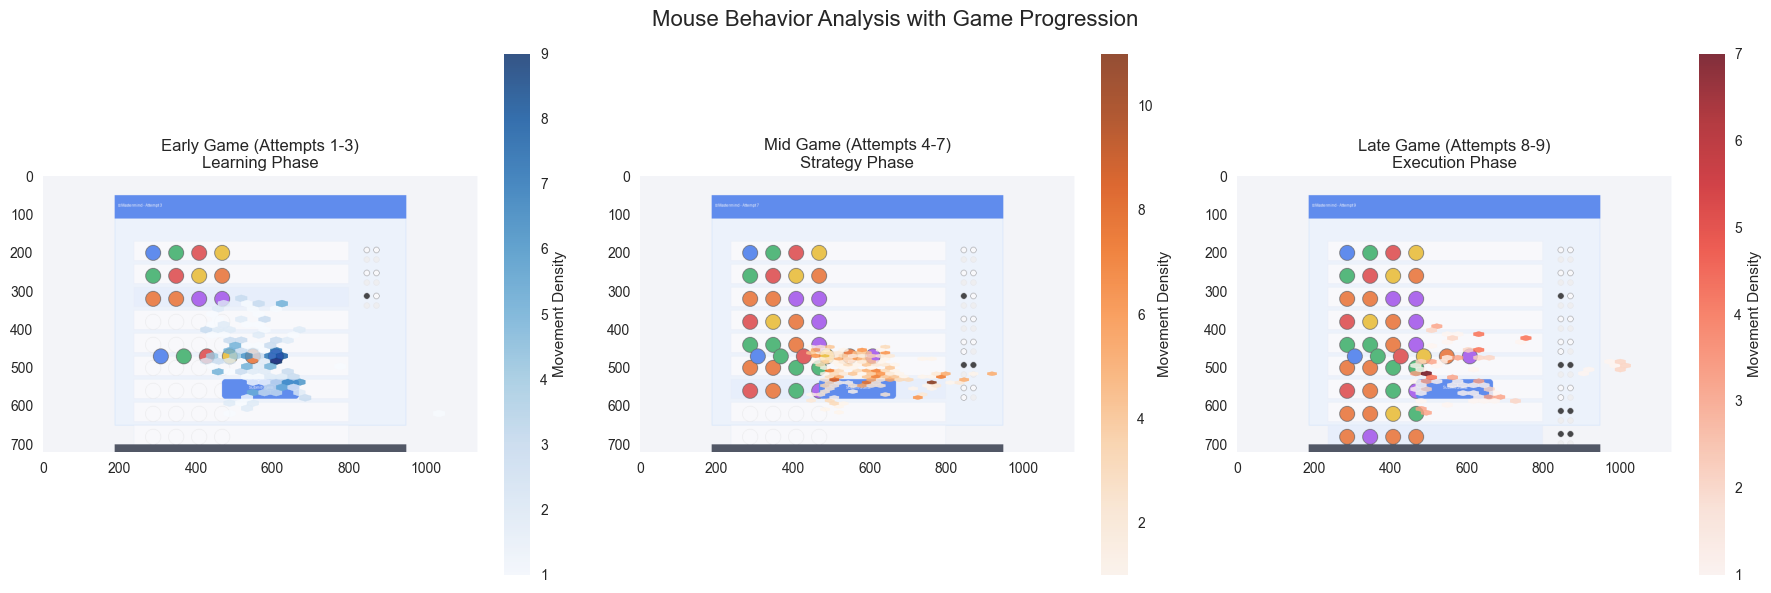

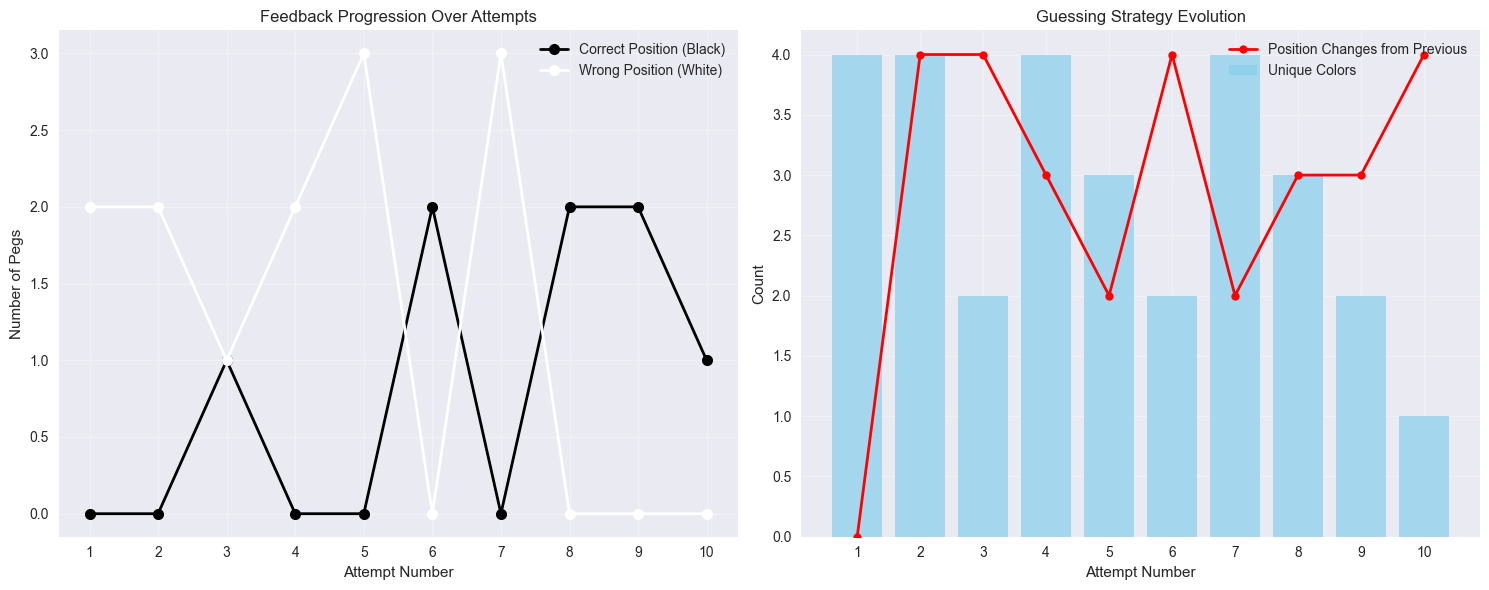


=== Strategy Analysis ===
Final score: 1 correct positions
Average unique colors per guess: 2.90
Learning progression: Started with 0 correct, ended with 1 correct

=== Mouse Movement Analysis by Game Phase ===
Early Game (1-3): 227 movements, 7.5 moves/sec
Mid Game (4-7): 348 movements, 6.1 moves/sec
Late Game (8+): 114 movements, 6.7 moves/sec

Total game duration: 105.6 seconds
Average time per attempt: 10.6 seconds

=== Guess Sequence ===
Attempt 1: ['Blue', 'Green', 'Red', 'Yellow'] → 0⚫ 2⚪
Attempt 2: ['Green', 'Red', 'Yellow', 'Orange'] → 0⚫ 2⚪
Attempt 3: ['Orange', 'Orange', 'Purple', 'Purple'] → 1⚫ 1⚪
Attempt 4: ['Red', 'Yellow', 'Orange', 'Purple'] → 0⚫ 2⚪
Attempt 5: ['Green', 'Green', 'Orange', 'Purple'] → 0⚫ 3⚪
Attempt 6: ['Orange', 'Orange', 'Green', 'Green'] → 2⚫ 0⚪
Attempt 7: ['Red', 'Orange', 'Green', 'Purple'] → 0⚫ 3⚪
Attempt 8: ['Orange', 'Orange', 'Yellow', 'Green'] → 2⚫ 0⚪
Attempt 9: ['Orange', 'Purple', 'Orange', 'Orange'] → 2⚫ 0⚪
Attempt 10: ['Green', 'Green', 'Gr

In [44]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from PIL import Image, ImageDraw, ImageFont
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection

# Load the JSON data
with open('HAIC_study_all-2.json', 'r') as f:
    data = json.load(f)

# Extract all relevant data
answers = data[0]['answers']['mastermind_task_solver_unlimited_1']['answer']
mouse_data_raw = answers['mastermindGame_mouseTrackingData']
guess_history_raw = answers['mastermindGame_guessHistory']
feedback_history_raw = answers['mastermindGame_feedbackHistory']

# Parse the data
mouse_data = json.loads(mouse_data_raw)
guess_history = json.loads(guess_history_raw)
feedback_history = json.loads(feedback_history_raw)

# Convert to DataFrame
df = pd.DataFrame(mouse_data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_relative'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

print("=== Game Data Summary ===")
print(f"Total attempts: {len(guess_history)}")
print(f"Mouse movements: {len(df)}")
print(f"Guess history: {guess_history}")
print(f"Feedback history: {feedback_history}")

def create_dynamic_game_interface(attempt_number, guess_history, feedback_history, width, height):
    """Create game interface that shows the current state at a specific attempt"""
    img = Image.new('RGB', (width, height), color='#f7f9fb')
    draw = ImageDraw.Draw(img)
    
    # Game area dimensions
    game_width = 760
    game_height = 600
    game_x = (width - game_width) // 2
    game_y = 50
    
    # Draw game container
    draw.rectangle([game_x, game_y, game_x + game_width, game_y + game_height], 
                   outline='#cfe6ff', fill='#eef6ff', width=2)
    
    # Draw title area
    draw.rectangle([game_x, game_y, game_x + game_width, game_y + 60], 
                   fill='#2563eb', outline='#2563eb')
    
    # Draw game board with submitted guesses
    board_y = game_y + 120
    
    # Only show rows up to the current attempt
    for i in range(min(attempt_number, 10)):
        row_y = board_y + i * 60
        
        # Row background - different color for current attempt
        if i == attempt_number - 1:
            row_color = '#e6f0ff'  # Highlight current attempt
        else:
            row_color = 'white'
            
        draw.rectangle([game_x + 50, row_y, game_x + game_width - 150, row_y + 50], 
                       fill=row_color, outline='#e6eefb')
        
        # Draw pegs with actual guess colors
        if str(i+1) in guess_history:
            guess_colors = guess_history[str(i+1)]
            color_map = {
                'Blue': '#2563eb', 'Green': '#16a34a', 'Red': '#dc2626',
                'Yellow': '#eab308', 'Orange': '#ea580c', 'Purple': '#9333ea'
            }
            
            for j, color_name in enumerate(guess_colors):
                peg_x = game_x + 80 + j * 60
                color = color_map.get(color_name, 'white')
                draw.ellipse([peg_x, row_y + 10, peg_x + 40, row_y + 50], 
                             outline='#333', fill=color, width=2)
        else:
            # Empty pegs for future rows
            for j in range(4):
                peg_x = game_x + 80 + j * 60
                draw.ellipse([peg_x, row_y + 10, peg_x + 40, row_y + 50], 
                             outline='#333', fill='white', width=2)
        
        # Draw feedback pegs
        feedback_x = game_x + game_width - 120
        if str(i+1) in feedback_history:
            fb = feedback_history[str(i+1)]
            black_pegs = fb.get('black', 0)
            white_pegs = fb.get('white', 0)
            
            # Draw feedback pegs in a 2x2 grid
            for k in range(4):
                row = k // 2
                col = k % 2
                fb_x = feedback_x + 10 + col * 25
                fb_y = row_y + 15 + row * 25
                
                if k < black_pegs:
                    draw.ellipse([fb_x, fb_y, fb_x + 15, fb_y + 15], 
                                 outline='#333', fill='black', width=1)
                elif k < black_pegs + white_pegs:
                    draw.ellipse([fb_x, fb_y, fb_x + 15, fb_y + 15], 
                                 outline='#333', fill='white', width=1)
                else:
                    draw.ellipse([fb_x, fb_y, fb_x + 15, fb_y + 15], 
                                 outline='#ddd', fill='#f0f0f0', width=1)
    
    # Draw empty rows for future attempts
    for i in range(attempt_number, 10):
        row_y = board_y + i * 60
        draw.rectangle([game_x + 50, row_y, game_x + game_width - 150, row_y + 50], 
                       fill='white', outline='#e6eefb', width=1)
        for j in range(4):
            peg_x = game_x + 80 + j * 60
            draw.ellipse([peg_x, row_y + 10, peg_x + 40, row_y + 50], 
                         outline='#ddd', fill='white', width=1)
    
    # Draw color palette
    palette_y = game_y + 400
    colors = ['#2563eb', '#16a34a', '#dc2626', '#eab308', '#ea580c', '#9333ea']
    for i, color in enumerate(colors):
        palette_x = game_x + 100 + i * 60
        draw.ellipse([palette_x, palette_y, palette_x + 40, palette_y + 40], 
                     outline='#333', fill=color, width=2)
    
    # Draw submit button
    button_x = game_x + (game_width - 200) // 2
    button_y = palette_y + 80
    draw.rounded_rectangle([button_x, button_y, button_x + 200, button_y + 50], 
                          radius=8, fill='#2563eb', outline='#2563eb')
    
    # Draw chat area
    chat_y = game_y + game_height + 50
    chat_width = game_width
    chat_height = 420
    draw.rounded_rectangle([game_x, chat_y, game_x + chat_width, chat_y + chat_height], 
                          radius=10, fill='white', outline='#e6eefb', width=2)
    draw.rectangle([game_x, chat_y, game_x + chat_width, chat_y + 40], 
                   fill='#0f172a', outline='#0f172a')
    
    # Add attempt counter
    try:
        font = ImageFont.load_default()
        draw.text((game_x + 10, game_y + 20), f"🎯 Mastermind - Attempt {attempt_number}", 
                 fill='white', font=font)
        draw.text((button_x + 70, button_y + 15), "Submit Guess", fill='white', font=font)
    except:
        pass
    
    return img

def visualize_mouse_movements_with_dynamic_interface(df, guess_history, feedback_history):
    """Create visualization showing mouse movements with evolving game interface"""
    
    screen_width = int(df['x'].max() + 100)
    screen_height = int(df['y'].max() + 100)
    
    # Create a figure with subplots for each attempt
    attempts = sorted(df['attempt'].unique())
    n_attempts = len(attempts)
    
    cols = min(3, n_attempts)
    rows = (n_attempts + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 8, rows * 6))
    fig.suptitle('Mouse Movements with Dynamic Game Interface Evolution', 
                 fontsize=16, fontweight='bold')
    
    if rows > 1 and cols > 1:
        axes_flat = axes.flatten()
    elif rows == 1 and cols > 1:
        axes_flat = axes
    else:
        axes_flat = [axes]
    
    for idx, attempt in enumerate(attempts):
        if idx < len(axes_flat):
            ax = axes_flat[idx]
            attempt_data = df[df['attempt'] == attempt]
            
            # Create interface for this attempt state
            background = create_dynamic_game_interface(
                attempt, guess_history, feedback_history, screen_width, screen_height
            )
            
            # Display background
            ax.imshow(background, extent=[0, screen_width, screen_height, 0])
            
            # Plot mouse movements for this attempt
            if len(attempt_data) > 0:
                # Color by time within attempt
                attempt_min_time = attempt_data['timestamp_relative'].min()
                attempt_data['time_in_attempt'] = attempt_data['timestamp_relative'] - attempt_min_time
                
                scatter = ax.scatter(attempt_data['x'], attempt_data['y'], 
                                   c=attempt_data['time_in_attempt'], 
                                   cmap='plasma', s=15, alpha=0.7)
                ax.plot(attempt_data['x'], attempt_data['y'], 'w-', alpha=0.3, linewidth=1)
                
                # Add start and end markers
                start_point = attempt_data.iloc[0]
                end_point = attempt_data.iloc[-1]
                ax.scatter(start_point['x'], start_point['y'], color='green', 
                          s=80, marker='o', label='Start', edgecolors='white', linewidth=2)
                ax.scatter(end_point['x'], end_point['y'], color='red', 
                          s=80, marker='s', label='End', edgecolors='white', linewidth=2)
            
            ax.set_xlim(0, screen_width)
            ax.set_ylim(screen_height, 0)
            
            # Add guess information to title
            guess_info = ""
            if str(attempt) in guess_history:
                guess = guess_history[str(attempt)]
                feedback = feedback_history.get(str(attempt), {})
                guess_info = f"\nGuess: {', '.join(guess)}\nFeedback: {feedback.get('black', 0)}⚫ {feedback.get('white', 0)}⚪"
            
            ax.set_title(f'Attempt {attempt}{guess_info}', fontsize=10)
            ax.grid(False)
            ax.legend()
    
    # Hide unused subplots
    for idx in range(len(attempts), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('dynamic_interface_mouse_movements.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_heatmap_with_game_progression(df, guess_history, feedback_history):
    """Create a heatmap that shows how mouse behavior changes as the game progresses"""
    
    screen_width = int(df['x'].max() + 100)
    screen_height = int(df['y'].max() + 100)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Mouse Behavior Analysis with Game Progression', fontsize=16)
    
    # 1. Early game (attempts 1-3)
    early_data = df[df['attempt'] <= 3]
    background_early = create_dynamic_game_interface(3, guess_history, feedback_history, 
                                                   screen_width, screen_height)
    ax1.imshow(background_early, extent=[0, screen_width, screen_height, 0], alpha=0.7)
    hexbin1 = ax1.hexbin(early_data['x'], early_data['y'], gridsize=20, cmap='Blues', 
                        alpha=0.8, mincnt=1)
    ax1.set_xlim(0, screen_width)
    ax1.set_ylim(screen_height, 0)
    ax1.set_title('Early Game (Attempts 1-3)\nLearning Phase')
    ax1.grid(False)
    plt.colorbar(hexbin1, ax=ax1, label='Movement Density')
    
    # 2. Mid game (attempts 4-7)
    mid_data = df[(df['attempt'] >= 4) & (df['attempt'] <= 7)]
    background_mid = create_dynamic_game_interface(7, guess_history, feedback_history, 
                                                 screen_width, screen_height)
    ax2.imshow(background_mid, extent=[0, screen_width, screen_height, 0], alpha=0.7)
    hexbin2 = ax2.hexbin(mid_data['x'], mid_data['y'], gridsize=20, cmap='Oranges', 
                        alpha=0.8, mincnt=1)
    ax2.set_xlim(0, screen_width)
    ax2.set_ylim(screen_height, 0)
    ax2.set_title('Mid Game (Attempts 4-7)\nStrategy Phase')
    ax2.grid(False)
    plt.colorbar(hexbin2, ax=ax2, label='Movement Density')
    
    # 3. Late game (attempts 8+)
    late_data = df[df['attempt'] >= 8]
    background_late = create_dynamic_game_interface(max(df['attempt']), guess_history, 
                                                  feedback_history, screen_width, screen_height)
    ax3.imshow(background_late, extent=[0, screen_width, screen_height, 0], alpha=0.7)
    hexbin3 = ax3.hexbin(late_data['x'], late_data['y'], gridsize=20, cmap='Reds', 
                        alpha=0.8, mincnt=1)
    ax3.set_xlim(0, screen_width)
    ax3.set_ylim(screen_height, 0)
    ax3.set_title(f'Late Game (Attempts 8-{max(df["attempt"])})\nExecution Phase')
    ax3.grid(False)
    plt.colorbar(hexbin3, ax=ax3, label='Movement Density')
    
    plt.tight_layout()
    plt.savefig('game_progression_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()

def analyze_strategy_evolution(guess_history, feedback_history):
    """Analyze how guessing strategy evolved based on feedback"""
    
    attempts = sorted([int(k) for k in guess_history.keys()])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot feedback progression
    black_pegs = [feedback_history[str(a)].get('black', 0) for a in attempts]
    white_pegs = [feedback_history[str(a)].get('white', 0) for a in attempts]
    
    ax1.plot(attempts, black_pegs, 'ko-', linewidth=2, markersize=8, label='Correct Position (Black)')
    ax1.plot(attempts, white_pegs, 'wo-', linewidth=2, markersize=8, 
             markeredgecolor='black', label='Wrong Position (White)')
    ax1.set_xlabel('Attempt Number')
    ax1.set_ylabel('Number of Pegs')
    ax1.set_title('Feedback Progression Over Attempts')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(attempts)
    
    # Calculate strategy metrics
    color_diversity = []
    position_changes = []
    
    for i, attempt in enumerate(attempts):
        guess = guess_history[str(attempt)]
        # Color diversity (number of unique colors in guess)
        unique_colors = len(set(guess))
        color_diversity.append(unique_colors)
        
        # Position changes (compare with previous guess if available)
        if i > 0:
            prev_guess = guess_history[str(attempts[i-1])]
            changes = sum(1 for j in range(4) if guess[j] != prev_guess[j])
            position_changes.append(changes)
        else:
            position_changes.append(0)
    
    ax2.bar(attempts, color_diversity, alpha=0.7, color='skyblue', label='Unique Colors')
    ax2.plot(attempts, position_changes, 'ro-', linewidth=2, markersize=6, 
             label='Position Changes from Previous')
    ax2.set_xlabel('Attempt Number')
    ax2.set_ylabel('Count')
    ax2.set_title('Guessing Strategy Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(attempts)
    
    plt.tight_layout()
    plt.savefig('strategy_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n=== Strategy Analysis ===")
    print(f"Final score: {black_pegs[-1]} correct positions")
    print(f"Average unique colors per guess: {np.mean(color_diversity):.2f}")
    print(f"Learning progression: Started with {black_pegs[0]} correct, ended with {black_pegs[-1]} correct")

# Run all enhanced visualizations
print("Creating enhanced visualizations with game progression...")

# 1. Dynamic interface visualization
visualize_mouse_movements_with_dynamic_interface(df, guess_history, feedback_history)

# 2. Game progression heatmaps
create_heatmap_with_game_progression(df, guess_history, feedback_history)

# 3. Strategy evolution analysis
analyze_strategy_evolution(guess_history, feedback_history)

# Additional detailed analysis
print("\n=== Mouse Movement Analysis by Game Phase ===")
for phase_name, phase_condition in [
    ("Early Game (1-3)", df['attempt'] <= 3),
    ("Mid Game (4-7)", (df['attempt'] >= 4) & (df['attempt'] <= 7)),
    ("Late Game (8+)", df['attempt'] >= 8)
]:
    phase_data = df[phase_condition]
    if len(phase_data) > 0:
        movements_per_second = len(phase_data) / (phase_data['timestamp_relative'].max() - phase_data['timestamp_relative'].min())
        print(f"{phase_name}: {len(phase_data)} movements, {movements_per_second:.1f} moves/sec")

print(f"\nTotal game duration: {df['timestamp_relative'].max():.1f} seconds")
print(f"Average time per attempt: {df['timestamp_relative'].max() / len(guess_history):.1f} seconds")

# Show the actual guess sequence
print("\n=== Guess Sequence ===")
for attempt in sorted([int(k) for k in guess_history.keys()]):
    guess = guess_history[str(attempt)]
    feedback = feedback_history[str(attempt)]
    print(f"Attempt {attempt}: {guess} → {feedback['black']}⚫ {feedback['white']}⚪")